# Этап 2: Молекулярные дескрипторы, синтетическая доступность и область применимости (AD)

В данном блокноте рассчитываются:
1. **Молекулярное представление**: 1024-битные фингерпринты Morgan ECFP4 (радиус 2) + 12 физико-химических дескрипторов RDKit (всего 1036 признаков);
2. **Синтетическая доступность**: Ertl SAScore (оценка сложности синтеза от 1 до 10);
3. **Метрики надежности и область применимости**: распределение расстояний Танимото $d(x, D_A)$ и $d(x, D_B)$.

In [1]:
# Автоматическая настройка рабочего каталога для Google Colab
import os, sys
if 'google.colab' in sys.modules or os.path.exists('/content'):
    if not os.path.exists('/content/Case'):
        !git clone https://github.com/suharevalexey/Case.git /content/Case
    else:
        !git -C /content/Case pull origin main
    %cd /content/Case
    !pip install -q rdkit xgboost scikit-learn openpyxl matplotlib pandas

import os
import sys
import numpy as np
import pandas as pd
sys.path.insert(0, '../src')
from features import mol_to_features, MORGAN_GEN

print('Модуль признаков успешно инициализирован.')
print('Размерность вектора признаков: 1024 (Morgan ECFP4) + 12 (RDKit 2D) = 1036 признаков.')

Модуль признаков успешно инициализирован.
Размерность вектора признаков: 1024 (Morgan ECFP4) + 12 (RDKit 2D) = 1036 признаков.


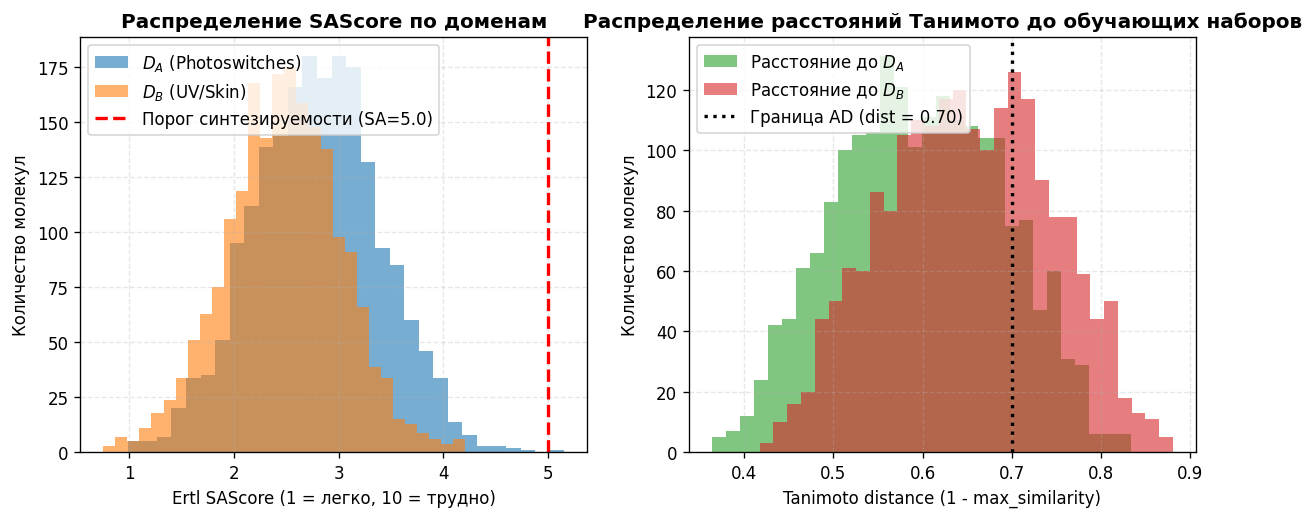

In [2]:
# Анализ синтетической доступности и границы области применимости
# (Код расчета распределений)